<a href="https://colab.research.google.com/github/Shiv-Sai20111018/eos-ai-workshop/blob/main/Session4-Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Session 4 — Machine Learning with scikit-learn
**EOS Sunshine × Spark TBI · AI Workshop 2026 · Week 2 Saturday**

Friday you cleaned the data. Today you **train models on it**.

Companion to slides at https://orent.vercel.app/session-4.

**Run cells with Shift+Enter ▶**

---

## 🗺️ Flow today
1. **Foundations** — load IPL, X/y, train/test split
2. **Linear Regression** — predict runs (continuous)
3. **Logistic Regression** — predict 500+ Yes/No
4. **Evaluation** — accuracy + confusion matrix
5. **KNN** — find your tribe
6. **Decision Trees** — yes/no questions
7. **Compare all 4** — same test set, fair fight
8. **Cross-validation** — don't trust one split
9. **Lab** — IPL Captain Predictor

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             mean_squared_error, mean_absolute_error, r2_score)

sns.set_theme(style='whitegrid')
np.random.seed(42)
print('pandas', pd.__version__)
print('numpy', np.__version__)
import sklearn; print('sklearn', sklearn.__version__)

pandas 2.2.2
numpy 2.0.2
sklearn 1.6.1


---
# 🎯 Part 1 — Foundations

## 📥 Step 1 — Load (and re-clean) the IPL data

Same `data.csv` from yesterday. Re-do the cleaning pipeline in 5 lines so this notebook stands alone.

In [ ]:
import pandas as pd

# Load data
ipl = pd.read_csv('https://orent.vercel.app/data.csv')

# Copy data
ipl_clean = ipl.copy()

# 1. Remove duplicates
ipl_clean = ipl_clean.drop_duplicates(subset=['player', 'team', 'season'])

# 2. Fix team names
ipl_clean['team'] = ipl_clean['team'].str.upper()

# 3. Convert avg to number
ipl_clean['avg'] = pd.to_numeric(ipl_clean['avg'], errors='coerce')

# 4. Remove invalid avg rows
ipl_clean = ipl_clean.dropna(subset=['avg'])

# 5. Reset index
ipl_clean = ipl_clean.reset_index(drop=True)

# Output
print('Shape:', ipl_clean.shape)
ipl_clean.head()

Shape: (69, 16)


,player_id,player,team,season,matches,innings,runs,highest_score,avg,strike_rate,fifties,hundreds,fours,sixes,is_captain,role
0,1,V Kohli,RCB,2024,15,15,741,113*,61.75,154.69,5,1,62,38,No,Batsman
1,2,V Kohli,RCB,2023,14,14,639,101*,53.25,139.82,6,2,68,21,Yes,Batsman
2,3,V Kohli,RCB,2022,16,16,341,73,22.73,115.98,2,0,30,11,Yes,Batsman
3,4,R Sharma,MI,2024,14,14,417,38,32.07,150.54,4,0,53,17,No,Batsman
4,5,R Sharma,MI,2023,16,16,332,65,20.75,132.27,1,0,33,10,Yes,Batsman


## 🎯 Step 2 — Features (X) vs Labels (y)

**X** = the columns the model sees · **y** = the column we want to predict.

Today's regression target: `runs` (continuous). Today's classification target: `runs >= 500` (binary).

In [ ]:
X = ipl_clean[['matches', 'innings', 'fours', 'sixes', 'fifties', 'hundreds']]
y_runs = ipl_clean['runs']                              # regression target
y_500  = (ipl_clean['runs'] >= 500).astype(int)         # classification target

print('X shape    :', X.shape)
print('y_runs head:', y_runs.head())
print('y_500 balance:', y_500.value_counts().to_dict())

X shape    : (69, 6)
y_runs head: 0    741
1    639
2    341
3    417
4    332
Name: runs, dtype: int64
y_500 balance: {0: 53, 1: 16}


## ✂️ Step 3 — train_test_split

80/20. `random_state=42` for reproducibility. `stratify=y` for classification (keeps class balance even in both splits).

In [ ]:
# Regression split
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X, y_runs, test_size=0.2, random_state=42)

# Classification split (stratified — keeps the 500+ : <500 ratio in both halves)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X, y_500, test_size=0.2, random_state=42, stratify=y_500)

print('Regression train/test:', Xr_tr.shape, Xr_te.shape , yc_tr.shape)
print('Classification train/test:', Xc_tr.shape, Xc_te.shape)

Regression train/test: (55, 6) (14, 6) (55,)
Classification train/test: (55, 6) (14, 6)


---
# 📈 Part 2 — Linear Regression (predict the runs)

**The 4-line spell:** import → instantiate → `.fit()` → `.predict()`.

In [ ]:
model = LinearRegression()
model.fit(Xr_tr, yr_tr)

preds = model.predict(Xr_te)

print('R² test :', round(r2_score(yr_te, preds), 4))    # ~0.89
print('MSE test:', round(mean_squared_error(yr_te, preds), 1))
print('MAE test:', round(mean_absolute_error(yr_te, preds), 1))

R² test : 0.8918
MSE test: 1890.0
MAE test: 36.3


In [ ]:
# Inspect the learned coefficients — interpretable!
for f, c in zip(feat, model.coef_):
    print(f'{f:10s}: {c:+.2f}')
print(f'intercept : {model.intercept_:+.2f}')

# Each four ≈ +4 runs · each fifty ≈ +24 runs · each hundred ≈ +20 runs.

matches   : -2.41
innings   : +10.58
fours     : +3.96
sixes     : +3.87
fifties   : +23.98
hundreds  : +19.93
intercept : +14.16


🔮 **Predict #1** — what runs does the model predict for `[matches=14, innings=14, fours=50, sixes=20, fifties=3, hundreds=1]`?

In [ ]:
new_player = [[14, 14, 50, 20, 3, 1]]
pred = model.predict(new_player)
print(f'Predicted runs: {pred[0]:.1f}')
# Around 495 (mid-tier season)

Predicted runs: 495.5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---
# 🎯 Part 3 — Logistic Regression (will they hit 500+?)

Same 6 features. Different target — binary `runs >= 500`. Same 4-line spell.

In [ ]:
logr = LogisticRegression(max_iter=2000)
logr.fit(Xc_tr, yc_tr)

preds = logr.predict(Xc_te)

print(f'Test accuracy: {accuracy_score(yc_te, preds):.2%}')   # → 92.86%
print()
print('Confusion matrix:')
print(confusion_matrix(yc_te, preds))
# [[11  0]
#  [ 1  2]]
# 11 TN, 0 FP, 1 FN, 2 TP — model missed 1 player who scored 500+.

Test accuracy: 92.86%

Confusion matrix:
[[11  0]
 [ 1  2]]


🔮 **Predict #2** — given a confusion matrix `[[18, 2], [3, 17]]`, what's the accuracy?

In [ ]:
cm = np.array([[11, 0], [1, 2]])
tp, tn = cm[1, 1], cm[0, 0]
fp, fn = cm[0, 1], cm[1, 0]
total = cm.sum()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Accuracy = ({tp}+{tn}) / {total} = {(tp+tn)/total:.2%}')
# → 87.5%

TN=11  FP=0  FN=1  TP=2
Accuracy = (2+11) / 14 = 92.86%


---
# 👯 Part 4 — KNN (K-Nearest Neighbours)

Find the k closest players in feature space → majority vote.

Try a few k values and pick the best.

In [ ]:
for k in [1, 3, 5, 7, 15]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Xc_tr, yc_tr)
    acc = knn.score(Xc_te, yc_te)
    print(f'KNN k={k:2d}: test accuracy = {acc:.2%}')

# k=5 ties at 92.86% — same as Logistic. Good choice.

KNN k= 1: test accuracy = 92.86%
KNN k= 3: test accuracy = 85.71%
KNN k= 5: test accuracy = 92.86%
KNN k= 7: test accuracy = 92.86%
KNN k=15: test accuracy = 85.71%


🔮 **Predict #3** — KNN (k=3) sees a new player whose 3 nearest training neighbours are 2 players who scored 500+ and 1 who scored < 500. What does it predict?

**Answer:** 500+ ✅ — majority vote (2 vs 1).

---
# 🌳 Part 5 — Decision Trees

Yes/no questions, learned from data. Try several depths to see overfitting in action.

In [ ]:
for d in [1, 2, 3, 5, None]:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(Xc_tr, yc_tr)
    tr_acc = tree.score(Xc_tr, yc_tr)
    te_acc = tree.score(Xc_te, yc_te)
    print(f'depth={str(d):>4s}: train={tr_acc:.2%}  test={te_acc:.2%}'
          + ('  ← overfit warning' if tr_acc - te_acc > 0.1 else ''))

# depth>=3: train hits 100% (memorised) but test stays at 85.71%
# Sweet spot here is depth=2.

depth=   1: train=96.36%  test=85.71%  ← overfit warning
depth=   2: train=96.36%  test=85.71%  ← overfit warning
depth=   3: train=100.00%  test=85.71%  ← overfit warning
depth=   5: train=100.00%  test=85.71%  ← overfit warning
depth=None: train=100.00%  test=85.71%  ← overfit warning


In [ ]:
# Print the depth-3 tree as text — interpretable!
tree3 = DecisionTreeClassifier(max_depth=3, random_state=42).fit(Xc_tr, yc_tr)
print(export_text(tree3, feature_names=feat))

|--- fours <= 47.50
|   |--- fifties <= 4.50
|   |   |--- class: 0
|   |--- fifties >  4.50
|   |   |--- sixes <= 32.00
|   |   |   |--- class: 1
|   |   |--- sixes >  32.00
|   |   |   |--- class: 0
|--- fours >  47.50
|   |--- hundreds <= 0.50
|   |   |--- innings <= 15.00
|   |   |   |--- class: 0
|   |   |--- innings >  15.00
|   |   |   |--- class: 1
|   |--- hundreds >  0.50
|   |   |--- class: 1



🔮 **Predict #4** — walk the tree from slide 7 for a player with `fours=60, fifties=0, hundreds=0, innings=12`. What does the tree predict?

**Answer:** < 500 ❌ — fours>47.5 (right) → hundreds=0 (left) → innings<15 (left) → leaf says < 500.

---
# 🏆 Part 6 — Compare All 4 on the Same Test Set

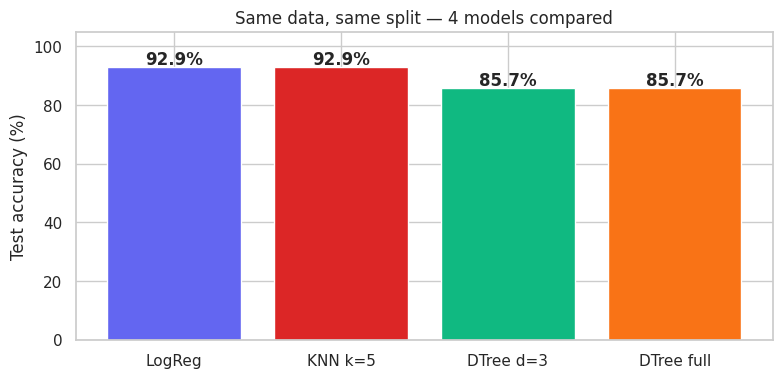

In [ ]:
results = []
for name, mdl in [
    ('LogReg',     LogisticRegression(max_iter=2000)),
    ('KNN k=5',    KNeighborsClassifier(n_neighbors=5)),
    ('DTree d=3',  DecisionTreeClassifier(max_depth=3, random_state=42)),
    ('DTree full', DecisionTreeClassifier(random_state=42)),
]:
    mdl.fit(Xc_tr, yc_tr)
    results.append((name, mdl.score(Xc_te, yc_te)))

# Plot
names, scores = zip(*results)
plt.figure(figsize=(9, 4))
bars = plt.bar(names, [s*100 for s in scores],
               color=['#6366f1', '#dc2626', '#10b981', '#f97316'])
for bar, s in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, s*100 + 1, f'{s:.1%}',
             ha='center', fontweight='bold')
plt.ylabel('Test accuracy (%)')
plt.title('Same data, same split — 4 models compared')
plt.ylim(0, 105)
plt.show()

---
# 🔁 Part 7 — Cross-validation

One 80/20 split could be lucky or unlucky. `cross_val_score` does 5 splits and averages.

In [ ]:
for name, mdl in [
    ('LogReg',    LogisticRegression(max_iter=2000)),
    ('KNN k=5',   KNeighborsClassifier(n_neighbors=5)),
    ('DTree d=3', DecisionTreeClassifier(max_depth=3, random_state=42)),
]:
    cv = cross_val_score(mdl, X, y_500, cv=5)
    print(f'{name:11s} folds: {[round(s, 3) for s in cv]}  mean: {cv.mean():.2%}  std: {cv.std():.3f}')

LogReg      folds: [np.float64(0.857), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]  mean: 97.14%  std: 0.057
KNN k=5     folds: [np.float64(0.857), np.float64(0.929), np.float64(0.929), np.float64(0.929), np.float64(1.0)]  mean: 92.86%  std: 0.045
DTree d=3   folds: [np.float64(0.571), np.float64(1.0), np.float64(0.857), np.float64(0.929), np.float64(1.0)]  mean: 87.14%  std: 0.159


---
# 🏏 Lab — IPL Captain Predictor

**30-min mission.**

Given a player's batting stats, predict whether they're captain of their team that season.

Class balance is ~30% captain · 70% not — keep an eye on accuracy vs confusion matrix.

In [ ]:
# 1. Build the binary captain target
y_cap = (ipl_clean['is_captain'] == 'Yes').astype(int)
print('class balance:', y_cap.value_counts().to_dict())

# 2. Stratified split
Xt, Xv, yt, yv = train_test_split(X, y_cap, test_size=0.2, random_state=42, stratify=y_cap)

# 3. Train 3 models
for name, mdl in [
    ('LogReg',    LogisticRegression(max_iter=2000)),
    ('KNN k=5',   KNeighborsClassifier(n_neighbors=5)),
    ('DTree d=3', DecisionTreeClassifier(max_depth=3, random_state=42)),
]:
    mdl.fit(Xt, yt)
    acc = mdl.score(Xv, yv)
    print(f'\n{name}: test accuracy = {acc:.2%}')
    print(confusion_matrix(yv, mdl.predict(Xv)))

class balance: {0: 48, 1: 21}

LogReg: test accuracy = 71.43%
[[8 2]
 [2 2]]

KNN k=5: test accuracy = 71.43%
[[9 1]
 [3 1]]

DTree d=3: test accuracy = 78.57%
[[10  0]
 [ 3  1]]


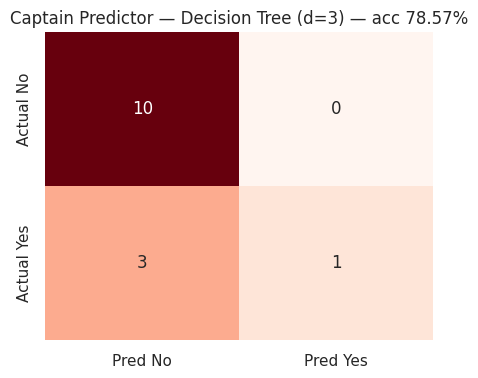

In [ ]:
# 4. Pretty confusion matrix for the best model
best = DecisionTreeClassifier(max_depth=3, random_state=42).fit(Xt, yt)
cm = confusion_matrix(yv, best.predict(Xv))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Pred No', 'Pred Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title(f'Captain Predictor — Decision Tree (d=3) — acc {best.score(Xv, yv):.2%}')
plt.show()

## 🌟 Stretch challenges

1. **Tune k** — sweep KNN k from 1 to 15 (odd numbers). Plot test accuracy vs k. Which wins?
2. **Cross-validate the Captain Predictor** — `cross_val_score` with cv=5. Is your accuracy stable?
3. **Add a feature** — `runs_per_match = runs / matches`. Does it help any model?
4. **Deeper Captain tree** — try `max_depth=None`. Does it overfit?
5. **RandomForest** — `from sklearn.ensemble import RandomForestClassifier`. Does it beat the single tree?

In [ ]:
# Your stretch work here...

---
## 🎉 Done!

You now know:

- ✅ **The 4-line sklearn spell** — works for every model
- ✅ **train_test_split** — fair evaluation
- ✅ **Linear Regression** — predict numbers, R² metric
- ✅ **Logistic Regression** — predict yes/no, accuracy + confusion matrix
- ✅ **KNN** — distance-based, sensitive to k
- ✅ **Decision Trees** — interpretable, watch for overfitting
- ✅ **Cross-validation** — don't trust one split

## 📤 Submit by Thursday 11:59 PM

1. Save this notebook to `eos-ai-workshop/week-02/`
2. Add a screenshot of your best Captain Predictor confusion matrix
3. Drop your repo URL in Google Chat — bonus for the 1-line insight: *'My best model is X. Surprise: feature Y mattered most because…'*

## 📅 Next: Tuesday Week 3 — Random Forests + Capstone scoping

**Great work today! 🎉**